In [1]:
# using Random Forest as baseline models
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer

pd.set_option('future.no_silent_downcasting', True)

In [2]:
# df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
# print(df.columns.tolist())

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_excel("/content/drive/MyDrive/BT4222/data/Main_Data_Bank_new.xlsx")

Mounted at /content/drive


In [3]:
# Drop irrelevant or redundant columns
df = df.drop(columns=[
    'Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype',
    'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'BANK WALLET',
    'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)',
    'Tilskudd i USD',  'Total Production Value(NOK)', 'Subsidy Dependency Ratio', 'Bransje'
])

print(df.columns.tolist())

# Clean column names: remove spaces and special characters
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^0-9A-Za-z_]", "", regex=True)
)

# Replace “ja/nei” type values with 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({
            'ja': 1, 'nei': 0,
            'Ja': 1, 'Nei': 0,
            'JA': 1, 'NEI': 0,
            '#DIV/0!': 0
        })

# Convert target column to numeric codes
target_col = 'NY_tilskuddskategori'
df[target_col] = (
    df[target_col]
    .replace({"XS": 0, "S": 1, "M": 2, "L": 3})
    .astype(float)
)

# Remove rows with missing target values
df = df.dropna(subset=[target_col])

# Split PRODUKSJON into multiple labels
df['PRODUKSJON_list'] = (
    df['PRODUKSJON']
    .fillna("")
    .apply(lambda x: [s.strip() for s in x.split(",") if s])
)

# Apply MultiLabelBinarizer to encode PRODUKSJON
mlb = MultiLabelBinarizer()
produksjon_encoded = pd.DataFrame(
    mlb.fit_transform(df['PRODUKSJON_list']),
    columns=mlb.classes_,
    index=df.index
)

# Merge encoded features back to the main dataframe
df = pd.concat([df, produksjon_encoded], axis=1)

# Drop original text columns
df = df.drop(columns=['PRODUKSJON', 'PRODUKSJON_list'])

# One-hot encode categorical location features
df = pd.get_dummies(df, columns=['Kommune', 'Fylke'], drop_first=True)

# Fill remaining missing values with 0
df = df.fillna(0)

print(df)

# Print summary of target variable distribution
print(f"Distribution of target variable '{target_col}':")
print(df[target_col].value_counts())


['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']
       NY_tilskuddskategori  Kompleks_produksjon_10  NY_KOMMUNESCORE  \
0                       3.0                       1                8   
1   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.7 MB/s eta 0:00:00
--- 1. Preparing data ---
Initial feature matrix shape: (37053, 439)
Target vector shape: (37053,)

Duplicate column names detected. Renaming...
Duplicated columns: ['Bier', 'Blomster', 'Egg', 'Frukt', 'Geit', 'Gress', 'Gris', 'Hest', 'Korn', 'Kylling', 'Melk', 'Potet', 'Sau', 'Storfe']
Column renaming completed.

--- 2. Splitting dataset ---
Training set shape: (33347, 439)
Testing set shape: (3706, 439)

--- 3. Initializing and training CatBoost model ---
0:	learn: 1.3536152	test: 1.3540339	best: 1.3540339 (0)	total: 83.6ms	remaining: 2m 47s
100:	learn: 0.5057040	test: 0.5188393	best: 0.5188393 (100)	total: 3.51s	remaining: 1m 6s
200:	learn: 0.3888122	test: 0.4057335	best: 0.4057335 (200)	total: 6.89s	remaining: 1m 1s
300:	learn: 0.3462036	test: 0.3658637	best: 0.3658637 (300)	total: 10.3s	remaining: 58.3s
400:	learn: 0.3205765	test: 0.3428764	best: 0.3428764 (400)	total: 14s	remaining: 55.7s
500:	learn: 0

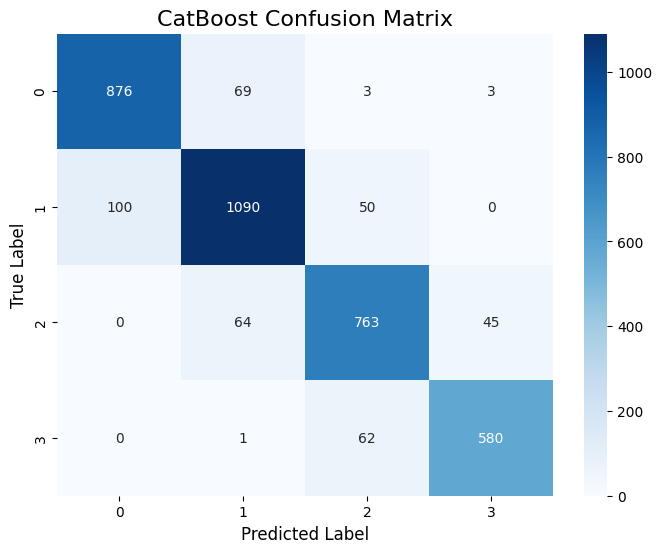


--- 5. Feature Importance Analysis ---
Top 20 Most Important Features:
                        Feature Id  Importances
0                       Korn_dekar    17.690844
1                          Sau_dyr    14.242050
2                      Gress_dekar    13.323726
3                       Storfe_dyr     7.577993
4   Production_Concentration_Index     7.464126
5                         Melk_dyr     5.019406
6           Kompleks_produksjon_10     4.169740
7                     Subsidy_Zone     3.507060
8                           Melk_1     2.085020
9                            Annet     1.919954
10                           Sau_1     1.885704
11                            Melk     1.738145
12                             Sau     1.621771
13                           Ingen     1.425960
14                        Storfe_1     1.356600
15                     Frukt_dekar     1.267650
16              BANK_WALLET_I_MNOK     1.189249
17                        Geit_dyr     1.125793
18              

/tmp/ipython-input-1977776016.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


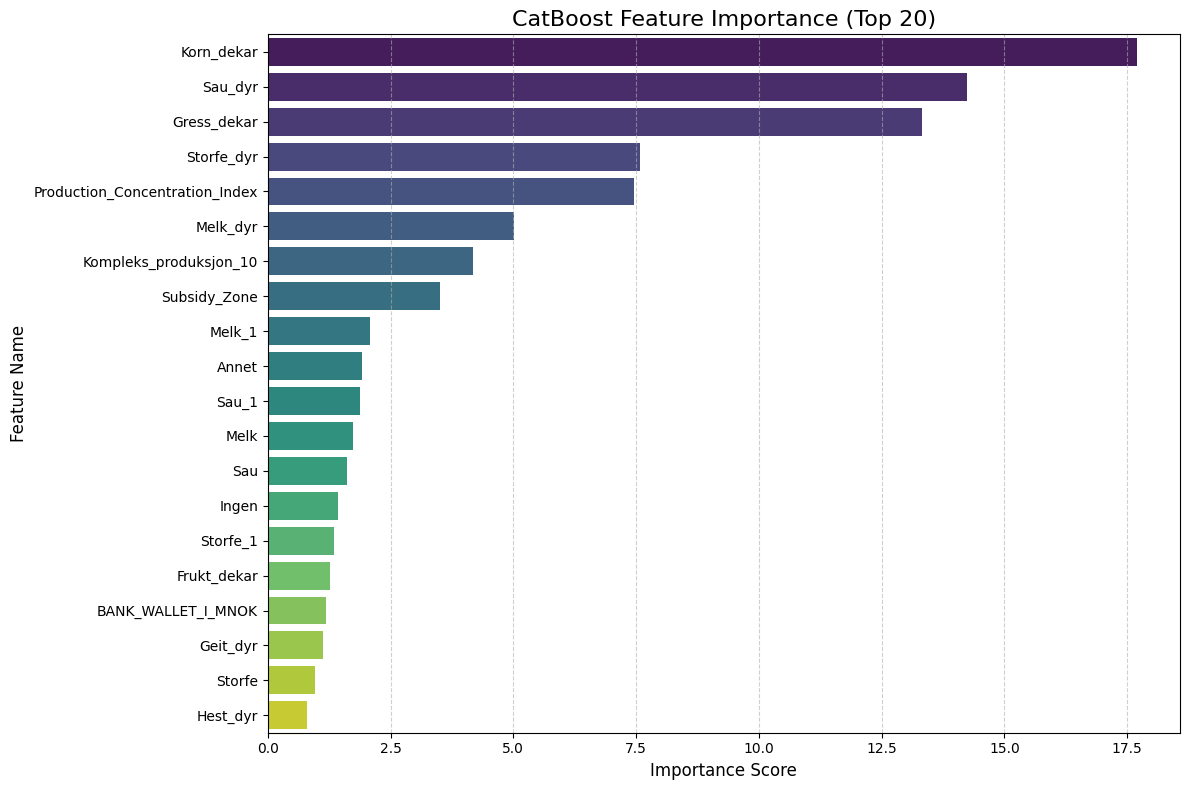

In [5]:
# If CatBoost or Seaborn are not installed, uncomment the following line:
!pip install catboost seaborn

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Prepare the final dataset ---
# The dataframe `df` already contains both the original features and the GNN-generated embeddings.
# We will use this enhanced dataframe for training.

print("--- 1. Preparing data ---")
target_col = 'NY_tilskuddskategori'
X_final = df.drop(columns=[target_col])
y_final = df[target_col]

print(f"Initial feature matrix shape: {X_final.shape}")
print(f"Target vector shape: {y_final.shape}\n")



# CatBoost requires all feature names to be unique.
# Our preprocessing steps may have created duplicate names.

cols = pd.Series(X_final.columns)

if cols.duplicated().any():
    print("Duplicate column names detected. Renaming...")
    duplicates = cols[cols.duplicated()].unique()
    print(f"Duplicated columns: {list(duplicates)}")

    # Rename duplicates by appending incremental suffixes
    col_counts = {}
    new_columns = []

    for col in X_final.columns:
        if col in col_counts:
            col_counts[col] += 1
            new_columns.append(f"{col}_{col_counts[col]}")
        else:
            col_counts[col] = 0
            new_columns.append(col)

    X_final.columns = new_columns
    print("Column renaming completed.\n")
else:
    print("No duplicate column names found.\n")


# --- 2. Train-test split ---
print("--- 2. Splitting dataset ---")
# Use stratified sampling to preserve class distribution across train/test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.1, random_state=42, stratify=y_final
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")


# --- 3. Initialize and train CatBoost model ---
print("--- 3. Initializing and training CatBoost model ---")

model_cb = CatBoostClassifier(
    iterations=2000,           # Number of trees
    learning_rate=0.02,        # Learning rate
    depth=8,                   # Maximum tree depth
    loss_function='MultiClass', # Multi-class loss
    eval_metric='MultiClass',   # Evaluation metric
    random_seed=42,             # Random seed for reproducibility
    verbose=100                 # Log training every 100 iterations
)

# Fit the model with early stopping to avoid overfitting
model_cb.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200  # Stop if no improvement for 200 rounds
)


# --- 4. Evaluate model performance on the test set ---
print("\n--- 4. Evaluating model performance ---")

y_pred = model_cb.predict(X_test)
y_pred_proba = model_cb.predict_proba(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Multi-class ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"Model ROC AUC Score: {roc_auc:.4f}\n")

# Classification report
class_names = ['0', '1', '2', '3']  # Original class labels from label encoder
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))

# Confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[str(c) for c in class_names],
    yticklabels=[str(c) for c in class_names]
)
plt.title('CatBoost Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()


# --- 5. Feature importance analysis ---
print("\n--- 5. Feature Importance Analysis ---")

feature_importance = model_cb.get_feature_importance(prettified=True)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Importances", y="Feature Id",
    data=feature_importance.head(20),
    palette="viridis"
)
plt.title('CatBoost Feature Importance (Top 20)', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
